In [1]:
import glob
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

NUM_CLEAVER_SENSORS = 16
NUM_C8_SENSORS = 7

# Import Temperature Data into Pandas Dataframes

In [2]:
# mount drive now that in Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd '/content/drive/MyDrive/JIRP_2022_Lapse_Rate_Project'

/content/drive/.shortcut-targets-by-id/1NL106H_XAIZZNAId05ru7dILq4YY25nB/JIRP_2022_Lapse_Rate_Project


In [ ]:
path = 'Data/iButton/heather_temp_profile_07192022/' # old path: '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/'
files = glob.glob(path+'*.csv')
print(files)

['Data/iButton/heather_temp_profile_07192022/B_H1A.csv', 'Data/iButton/heather_temp_profile_07192022/H_H2A.csv', 'Data/iButton/heather_temp_profile_07192022/S_H8A.csv', 'Data/iButton/heather_temp_profile_07192022/K_H4A.csv', 'Data/iButton/heather_temp_profile_07192022/M_H5A.csv', 'Data/iButton/heather_temp_profile_07192022/O_H6A.csv', 'Data/iButton/heather_temp_profile_07192022/R_H7A.csv', 'Data/iButton/heather_temp_profile_07192022/J_H3A.csv', 'Data/iButton/heather_temp_profile_07192022/c_H1B.csv', 'Data/iButton/heather_temp_profile_07192022/d_H2B.csv', 'Data/iButton/heather_temp_profile_07192022/N_H5B.csv', 'Data/iButton/heather_temp_profile_07192022/L_H4B.csv', 'Data/iButton/heather_temp_profile_07192022/i_H3B.csv', 'Data/iButton/heather_temp_profile_07192022/p_H6B.csv.csv', 'Data/iButton/heather_temp_profile_07192022/Q_H7B.csv', 'Data/iButton/heather_temp_profile_07192022/T_H8B.csv']


In [ ]:
file0_id = files[0].split('/')[-1].split('.csv')[0]
print(file0_id)

B_H1A


In [ ]:
# Load cleaver temperatures
file0_id = files[0].split('/')[-1].split('.csv')[0]
dfm = pd.read_csv(files[0], header=13, encoding='cp1252', index_col=0, 
                  names=['Unit0', file0_id])
dfm.index = pd.to_datetime(dfm.index, format='%m/%d/%y %I:%M:%S %p') 
if dfm['Unit0'][0] == 'F':
    dfm[file0_id] = (df[file_id] - 32) / (9/5)
dfm['day'] = dfm.index.day
dfm['hour'] = dfm.index.hour
dfm = dfm.groupby(['day','hour']).mean()
dfm = pd.DataFrame(dfm[file0_id])

for ii, file in enumerate(files[1:]):
    file_id = file.split('/')[-1].split('.csv')[0]
    df = pd.read_csv(file, header=13, encoding='cp1252', index_col=0,
                     names=['Unit'+str(ii+1), file_id])
    df.index = pd.to_datetime(df.index, format='%m/%d/%y %I:%M:%S %p')
    if df['Unit'+str(ii+1)][0] == 'F':
        df[file_id] = (df[file_id] - 32) / (9/5)
    df['day'] = df.index.day
    df['hour'] = df.index.hour
    df = df.groupby(['day','hour']).mean()
    #print(df[file_id].head(10))
    dfm = dfm.join(df[file_id])

dfm.tail(10)

B_H1A     H_H2A     S_H8A     K_H4A     M_H5A     O_H6A  \
day hour                                                               
24  3     2.833333  3.000000  3.000000  4.000000  4.000000  4.083333   
    4     2.750000  3.166667  3.083333  4.000000  3.916667  4.333333   
    5     2.500000  3.000000  2.583333  3.583333  4.000000  4.083333   
    6     2.166667  2.916667  2.500000  3.500000  4.000000  4.250000   
    7     2.666667  3.416667  2.916667  3.750000  4.416667  4.833333   
    8     3.583333  4.166667  3.583333  4.500000  4.666667  5.250000   
    9     4.000000  4.500000  4.083333  5.000000  5.000000  5.500000   
    10    4.416667  4.750000  4.666667  5.083333  5.083333  5.916667   
    11    6.833333  5.916667  5.916667  6.000000  6.000000  6.416667   
    12    8.700000  6.600000  6.400000  6.666667  6.666667  7.083333   

             R_H7A     J_H3A  c_H1B  d_H2B  N_H5B  L_H4B  i_H3B  p_H6B  Q_H7B  \
day hour                                                                        
24  3     4.500000  5.000000    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
    4     4.500000  5.000000    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
    5     4.500000  5.000000    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
    6     4.500000  5.083333    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
    7     4.916667  5.583333    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
    8     5.250000  6.000000    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
    9     5.500000  6.166667    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
    10    5.916667  6.666667    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
    11    6.583333  7.583333    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
    12    6.666667  7.500000    NaN    NaN    NaN    NaN    NaN    NaN    NaN   

          T_H8B  
day hour         
24  3       NaN  
    4       NaN  
    5       NaN  
    6       NaN  
    7       NaN  
    8       NaN  
    9       NaN  
    10      NaN  
    11      NaN  
    12      NaN

In [ ]:
# Load C8 temperatures
path = 'Data/iButton/c8_profile_07232022/' # '/Users/jabadgeley/JIRP/data/iButton_Data/c8_profile_07232022/'
files = glob.glob(path+'*.csv')
print(files)

for ii, file in enumerate(files):
    file_id = file.split('/')[-1].split('.csv')[0]
    df = pd.read_csv(file, header=13, encoding='cp1252', index_col=0,
                     names=['Unit'+str(ii+1), file_id])
    df.index = pd.to_datetime(df.index, format='%m/%d/%y %I:%M:%S %p')
    if df['Unit'+str(ii+1)][0] == 'F':
        df[file_id] = (df[file_id] - 32) / (9/5)
    df['day'] = df.index.day
    df['hour'] = df.index.hour
    df = df.groupby(['day','hour']).mean()
    dfm = dfm.join(df[file_id])

dfm['time'] = pd.to_datetime(['7/'+str(dfm.index[ii][0])+'/22 '+str(dfm.index[ii][1]) for ii in range(len(dfm.index))], format='%m/%d/%y %H')

['Data/iButton/c8_profile_07232022/I_c8.csv', 'Data/iButton/c8_profile_07232022/T_c8.csv', 'Data/iButton/c8_profile_07232022/F_c8.csv', 'Data/iButton/c8_profile_07232022/Q_c8.csv', 'Data/iButton/c8_profile_07232022/N_c8.csv', 'Data/iButton/c8_profile_07232022/P_c8.csv', 'Data/iButton/c8_profile_07232022/L_c8.csv']


In [ ]:
dfm.tail(10)

B_H1A     H_H2A     S_H8A     K_H4A     M_H5A     O_H6A  \
day hour                                                               
24  3     2.833333  3.000000  3.000000  4.000000  4.000000  4.083333   
    4     2.750000  3.166667  3.083333  4.000000  3.916667  4.333333   
    5     2.500000  3.000000  2.583333  3.583333  4.000000  4.083333   
    6     2.166667  2.916667  2.500000  3.500000  4.000000  4.250000   
    7     2.666667  3.416667  2.916667  3.750000  4.416667  4.833333   
    8     3.583333  4.166667  3.583333  4.500000  4.666667  5.250000   
    9     4.000000  4.500000  4.083333  5.000000  5.000000  5.500000   
    10    4.416667  4.750000  4.666667  5.083333  5.083333  5.916667   
    11    6.833333  5.916667  5.916667  6.000000  6.000000  6.416667   
    12    8.700000  6.600000  6.400000  6.666667  6.666667  7.083333   

             R_H7A     J_H3A  c_H1B  d_H2B  ...  Q_H7B  T_H8B  I_c8  T_c8  \
day hour                                    ...                             
24  3     4.500000  5.000000    NaN    NaN  ...    NaN    NaN   NaN   NaN   
    4     4.500000  5.000000    NaN    NaN  ...    NaN    NaN   NaN   NaN   
    5     4.500000  5.000000    NaN    NaN  ...    NaN    NaN   NaN   NaN   
    6     4.500000  5.083333    NaN    NaN  ...    NaN    NaN   NaN   NaN   
    7     4.916667  5.583333    NaN    NaN  ...    NaN    NaN   NaN   NaN   
    8     5.250000  6.000000    NaN    NaN  ...    NaN    NaN   NaN   NaN   
    9     5.500000  6.166667    NaN    NaN  ...    NaN    NaN   NaN   NaN   
    10    5.916667  6.666667    NaN    NaN  ...    NaN    NaN   NaN   NaN   
    11    6.583333  7.583333    NaN    NaN  ...    NaN    NaN   NaN   NaN   
    12    6.666667  7.500000    NaN    NaN  ...    NaN    NaN   NaN   NaN   

          F_c8  Q_c8  N_c8  P_c8  L_c8                time  
day hour                                                    
24  3      NaN   NaN   NaN   NaN   NaN 2022-07-24 03:00:00  
    4      NaN   NaN   NaN   NaN   NaN 2022-07-24 04:00:00  
    5      NaN   NaN   NaN   NaN   NaN 2022-07-24 05:00:00  
    6      NaN   NaN   NaN   NaN   NaN 2022-07-24 06:00:00  
    7      NaN   NaN   NaN   NaN   NaN 2022-07-24 07:00:00  
    8      NaN   NaN   NaN   NaN   NaN 2022-07-24 08:00:00  
    9      NaN   NaN   NaN   NaN   NaN 2022-07-24 09:00:00  
    10     NaN   NaN   NaN   NaN   NaN 2022-07-24 10:00:00  
    11     NaN   NaN   NaN   NaN   NaN 2022-07-24 11:00:00  
    12     NaN   NaN   NaN   NaN   NaN 2022-07-24 12:00:00  

[10 rows x 24 columns]

In [ ]:
site_ids = list(dfm.columns)[:-1]
site_elevs = {}
for site_id in site_ids:
    if site_id == 'J_H3A':
        site_elevs[site_id] = 1343
    elif site_id == 'T_H8B':
        site_elevs[site_id] = 1343
    elif site_id == 'Q_H7B':
        site_elevs[site_id] = 1403 
    elif site_id == 'R_H7A':
        site_elevs[site_id] = 1403 
    elif site_id == 'p_H6B':
        site_elevs[site_id] = 1451 
    elif site_id == 'O_H6A':
        site_elevs[site_id] = 1451 
    elif site_id == 'i_H3B':
        site_elevs[site_id] = 1605 
    elif site_id == 'S_H8A':
        site_elevs[site_id] = 1605
    elif site_id == 'N_H5B':
        site_elevs[site_id] = 1507 
    elif site_id == 'M_H5A':
        site_elevs[site_id] = 1507 
    elif site_id == 'd_H2B':
        site_elevs[site_id] = 1650 
    elif site_id == 'H_H2A':
        site_elevs[site_id] = 1650 
    elif site_id == 'L_H4B':
        site_elevs[site_id] = 1546 
    elif site_id == 'K_H4A':
        site_elevs[site_id] = 1546
    elif site_id == 'c_H1B':
        site_elevs[site_id] = 1698
    elif site_id == 'B_H1A':
        site_elevs[site_id] = 1698
    elif site_id == 'I_c8':
        site_elevs[site_id] = 2057
    elif site_id == 'L_c8':
        site_elevs[site_id] = 2108
    elif site_id == 'F_c8':
        site_elevs[site_id] = 2033
    elif site_id == 'P_c8':
        site_elevs[site_id] = 2159
    elif site_id == 'T_c8':
        site_elevs[site_id] = 2135
    elif site_id == 'Q_c8':
        site_elevs[site_id] = 2085
    elif site_id == 'N_c8':
        site_elevs[site_id] = 2007
print(site_elevs)

{'B_H1A': 1698, 'H_H2A': 1650, 'S_H8A': 1605, 'K_H4A': 1546, 'M_H5A': 1507, 'O_H6A': 1451, 'R_H7A': 1403, 'J_H3A': 1343, 'c_H1B': 1698, 'd_H2B': 1650, 'N_H5B': 1507, 'L_H4B': 1546, 'i_H3B': 1605, 'p_H6B': 1451, 'Q_H7B': 1403, 'T_H8B': 1343, 'I_c8': 2057, 'T_c8': 2135, 'F_c8': 2033, 'Q_c8': 2085, 'N_c8': 2007, 'P_c8': 2159, 'L_c8': 2108}


(738354.625, 738355.4166666666)

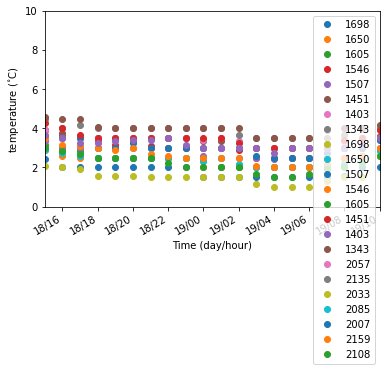

In [ ]:
fig = plt.figure()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%H'))
#plt.gca().xaxis.set_major_locator(mdates.DayLocator())
for jj, col in enumerate(list(dfm.columns)):
    if col == 'time':
        continue
    plt.plot(dfm['time'], dfm[col], 'o', label=site_elevs[col])
plt.gcf().autofmt_xdate()
plt.xlabel('Time (day/hour)')
plt.ylabel(r'temperature ($^{\circ}$C)')
plt.legend()
plt.ylim([0,10])
plt.xlim([datetime(2022, 7, 18, 15, 0, 0), datetime(2022, 7, 19, 10, 0, 0)])

# Get Lapse Rate for Time Period when all sensors on cleaver

In [ ]:
dfm_clip = dfm[(dfm['time'] >= datetime(2022, 7, 18, 15, 0, 0)) & 
               (dfm['time'] <= datetime(2022, 7, 19, 10, 0, 0))]
dfm_clip.shape

(20, 24)

In [ ]:
import numpy as np
dfm_avged = pd.DataFrame()
for key in site_elevs.keys():
    dfm_avged[str(site_elevs[key])] = np.zeros(dfm_clip.shape[0])
for key in site_elevs.keys():
    dfm_avged[str(site_elevs[key])] += np.array(dfm_clip[key])/2
dfm_avged.head(10)

,1698,1650,1605,1546,1507,1451,1403,1343,2057,2135,2033,2085,2007,2159,2108
0,2.250000,2.916667,3.083333,3.708333,3.458333,4.083333,3.791667,4.541667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.000000,2.666667,2.916667,3.375000,3.250000,3.875000,3.500000,4.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.958333,2.541667,2.750000,3.333333,3.250000,3.583333,3.375000,4.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.791667,2.500000,2.500000,3.208333,3.000000,3.500000,3.375000,4.041667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.791667,2.500000,2.500000,3.041667,3.000000,3.500000,3.416667,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.791667,2.500000,2.500000,3.166667,3.125000,3.500000,3.458333,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.750000,2.500000,2.500000,2.875000,3.000000,3.500000,3.458333,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.750000,2.500000,2.375000,2.791667,3.000000,3.500000,3.500000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.750000,2.500000,2.250000,2.750000,3.000000,3.500000,3.333333,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.500000,2.166667,2.166667,2.750000,2.791667,3.416667,3.208333,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dfm_mean = dfm_avged.mean(numeric_only=True)
dfm_mean

1698    1.670833
1650    2.347917
1605    2.291667
1546    2.829167
1507    2.887500
1451    3.400000
1403    3.285417
1343    3.931250
2057         NaN
2135         NaN
2033         NaN
2085         NaN
2007         NaN
2159         NaN
2108         NaN
dtype: float64

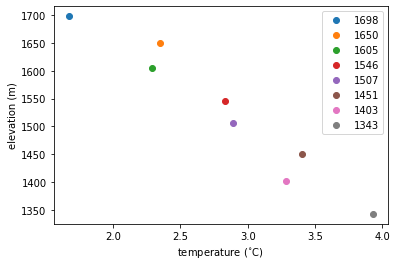

In [ ]:
fig = plt.figure()
for jj, col in enumerate(list(dfm_mean.index)):
    if (dfm_mean[col] > 0):
        plt.plot(dfm_mean[col], int(col), 'o', label=col)
plt.xlabel(r'temperature ($^{\circ}$C)')
plt.ylabel('elevation (m)')
plt.legend()
plt.show()

In [ ]:
dfm_mean.index

Index(['1698', '1650', '1605', '1546', '1507', '1451', '1403', '1343', '2057',
       '2135', '2033', '2085', '2007', '2159', '2108'],
      dtype='object')

In [ ]:
import numpy as np

Ts = np.empty(int(NUM_CLEAVER_SENSORS/2))
elvs = np.empty(int(NUM_CLEAVER_SENSORS/2))
for jj, col in enumerate(list(dfm_mean.index)[:int(NUM_CLEAVER_SENSORS/2)]):
    Ts[jj] = dfm_mean[col]
    elvs[jj] = col

In [ ]:
from scipy import stats

significance_threshold = 0.05

r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.9734290872614085
P-value = 4.596891502316478e-05
Slope =  -0.005678667690659885
Intercept =  11.492566478640322


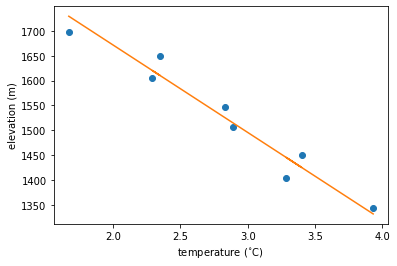

In [ ]:
elvs_predict = (Ts - intercept) / slope

fig = plt.figure()
plt.plot(Ts, elvs, 'o')
plt.plot(Ts, elvs_predict, '-')
plt.xlabel(r'temperature ($^{\circ}$C)')
plt.ylabel('elevation (m)')
plt.show()

# Get lapse rate for C8 + Cleaver time period

In [ ]:
dfm_clip_c8 = dfm[(dfm['time'] >= datetime(2022, 7, 21, 18, 0, 0)) & 
                  (dfm['time'] <= datetime(2022, 7, 23, 8, 0, 0))]
dfm_clip_c8.head(3)

B_H1A     H_H2A     S_H8A     K_H4A     M_H5A     O_H6A  \
day hour                                                               
21  18    4.000000  4.666667  4.500000  5.750000  5.250000  6.166667   
    19    3.666667  4.500000  4.166667  5.666667  5.250000  6.166667   
    20    3.500000  4.083333  3.666667  5.000000  4.916667  5.666667   

             R_H7A     J_H3A  c_H1B  d_H2B  ...  Q_H7B  T_H8B      I_c8  \
day hour                                    ...                           
21  18    6.166667  7.500000    NaN    NaN  ...    NaN    NaN  1.333333   
    19    6.083333  7.416667    NaN    NaN  ...    NaN    NaN  0.750000   
    20    5.916667  6.666667    NaN    NaN  ...    NaN    NaN  0.166667   

              T_c8      F_c8      Q_c8      N_c8      P_c8      L_c8  \
day hour                                                               
21  18    1.500000  1.416667  0.916667  1.083333  1.166667  0.500000   
    19    0.833333  0.583333  0.166667  0.666667  1.000000  0.000000   
    20    0.166667  0.083333 -0.333333  0.333333  0.083333 -0.416667   

                        time  
day hour                      
21  18   2022-07-21 18:00:00  
    19   2022-07-21 19:00:00  
    20   2022-07-21 20:00:00  

[3 rows x 24 columns]

In [ ]:
# Remove irrelevant rows from dataframe
dfm_clip_c8 = dfm_clip_c8[['B_H1A','J_H3A', 'S_H8A', 'H_H2A', 'O_H6A', 'K_H4A', 'R_H7A', 'M_H5A', 'F_c8', 'P_c8', 'L_c8', 'T_c8', 'N_c8', 'I_c8', 'Q_c8']]
dfm_clip_c8.head(10)

B_H1A     J_H3A     S_H8A     H_H2A     O_H6A     K_H4A  \
day hour                                                               
21  18    4.000000  7.500000  4.500000  4.666667  6.166667  5.750000   
    19    3.666667  7.416667  4.166667  4.500000  6.166667  5.666667   
    20    3.500000  6.666667  3.666667  4.083333  5.666667  5.000000   
    21    3.000000  5.916667  3.416667  3.500000  5.000000  4.333333   
    22    2.500000  5.500000  2.833333  3.083333  4.333333  3.833333   
    23    2.500000  5.500000  2.833333  3.000000  4.083333  3.666667   
22  0     2.250000  5.333333  2.500000  3.000000  4.000000  3.500000   
    1     2.000000  5.416667  2.500000  2.666667  4.000000  3.416667   
    2     2.083333  5.250000  2.500000  2.833333  4.000000  3.250000   
    3     1.916667  4.666667  2.333333  2.416667  3.750000  2.916667   

             R_H7A     M_H5A      F_c8      P_c8      L_c8      T_c8  \
day hour                                                               
21  18    6.166667  5.250000  1.416667  1.166667  0.500000  1.500000   
    19    6.083333  5.250000  0.583333  1.000000  0.000000  0.833333   
    20    5.916667  4.916667  0.083333  0.083333 -0.416667  0.166667   
    21    5.250000  4.416667  0.000000 -0.500000 -0.666667 -0.500000   
    22    4.500000  3.750000 -0.500000 -0.916667 -1.000000 -0.666667   
    23    4.500000  3.500000 -0.416667 -0.833333 -1.000000 -0.500000   
22  0     4.500000  3.500000 -0.500000 -1.000000 -1.000000 -0.916667   
    1     4.500000  3.500000 -0.500000 -1.000000 -1.166667 -1.000000   
    2     4.500000  3.500000 -0.416667 -0.916667 -1.250000 -0.833333   
    3     4.083333  3.250000 -0.250000 -0.833333 -1.166667 -0.833333   

              N_c8      I_c8      Q_c8  
day hour                                
21  18    1.083333  1.333333  0.916667  
    19    0.666667  0.750000  0.166667  
    20    0.333333  0.166667 -0.333333  
    21    0.000000 -0.500000 -0.666667  
    22   -0.166667 -0.500000 -1.000000  
    23   -0.250000 -0.583333 -1.000000  
22  0     0.000000 -0.750000 -1.000000  
    1    -0.416667 -1.000000 -1.083333  
    2    -0.333333 -0.916667 -1.000000  
    3     0.000000 -0.750000 -1.083333

In [ ]:
dfm_mean_c8 = dfm_clip_c8.mean(numeric_only=True)
dfm_mean_c8

B_H1A    2.173077
J_H3A    4.854701
S_H8A    2.606838
H_H2A    2.651709
O_H6A    3.788462
K_H4A    3.348291
R_H7A    4.021368
M_H5A    3.241453
F_c8    -0.243590
P_c8    -0.574786
L_c8    -0.865385
T_c8    -0.465812
N_c8    -0.036325
I_c8    -0.521368
Q_c8    -0.824786
dtype: float64

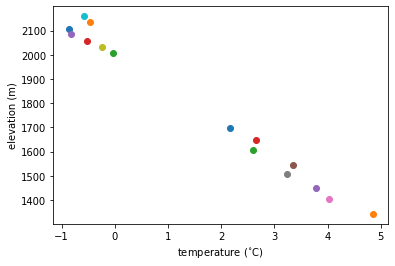

In [ ]:
fig = plt.figure()
for jj, col in enumerate(list(dfm_mean_c8.index)):
    plt.plot(dfm_mean_c8[col], site_elevs[col], 'o', label=site_elevs[col])
plt.xlabel(r'temperature ($^{\circ}$C)')
plt.ylabel('elevation (m)')
plt.show()

In [ ]:
import numpy as np

num_sensors = int(NUM_CLEAVER_SENSORS/2) + NUM_C8_SENSORS

Ts = np.empty(num_sensors)
elvs = np.empty(num_sensors)
for jj, col in enumerate(list(dfm_mean_c8.index)):
    Ts[jj] = dfm_mean_c8[col]
    elvs[jj] = site_elevs[col]

In [ ]:
from scipy import stats

significance_threshold = 0.05

r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.9936510629228879
P-value = 1.0099420792770088e-13
Slope =  -0.006837064758812846
Intercept =  13.753219989877724


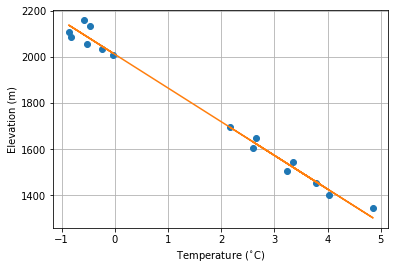

In [ ]:
elvs_predict = (Ts - intercept) / slope

fig = plt.figure()
plt.plot(Ts, elvs, 'o')
plt.plot(Ts, elvs_predict, '-')
plt.xlabel(r'Temperature ($^{\circ}$C)')
plt.ylabel('Elevation (m)')
plt.grid()
# plt.savefig('/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/overall_transect.png', dpi=300, bbox_inches='tight')
plt.show()

# Incorporate Sunstorm Profile

In [ ]:
# Load sunstorm temperatures
path = 'Data/iButton/mammory_sunstorm_profile_07252022/' # '/Users/jabadgeley/JIRP/data/iButton_Data/c8_profile_07232022/'
files = glob.glob(path+'*.csv')
print(files)

for ii, file in enumerate(files):
    file_id = file.split('/')[-1].split('.csv')[0]
    df = pd.read_csv(file, header=13, encoding='cp1252', index_col=0,
                     names=['Unit'+str(ii+1), file_id])
    df.index = pd.to_datetime(df.index, format='%m/%d/%y %I:%M:%S %p')
    if df['Unit'+str(ii+1)][0] == 'F':
        df[file_id] = (df[file_id] - 32) / (9/5)
    df['day'] = df.index.day
    df['hour'] = df.index.hour
    df = df.groupby(['day','hour']).mean()
    dfm_clip_c8 = dfm_clip_c8.join(df[file_id])

['Data/iButton/mammory_sunstorm_profile_07252022/C_MS1.csv', 'Data/iButton/mammory_sunstorm_profile_07252022/D_MS2.csv', 'Data/iButton/mammory_sunstorm_profile_07252022/E_MS3.csv', 'Data/iButton/mammory_sunstorm_profile_07252022/A_MS4.csv', 'Data/iButton/mammory_sunstorm_profile_07252022/MT1_MS6.csv', 'Data/iButton/mammory_sunstorm_profile_07252022/MT4_MS5.csv', 'Data/iButton/mammory_sunstorm_profile_07252022/MT2_MT7.csv', 'Data/iButton/mammory_sunstorm_profile_07252022/MT3_MS8.csv']


In [ ]:
dfm_clip_c8.head(10)

B_H1A     J_H3A     S_H8A     H_H2A     O_H6A     K_H4A  \
day hour                                                               
21  18    4.000000  7.500000  4.500000  4.666667  6.166667  5.750000   
    19    3.666667  7.416667  4.166667  4.500000  6.166667  5.666667   
    20    3.500000  6.666667  3.666667  4.083333  5.666667  5.000000   
    21    3.000000  5.916667  3.416667  3.500000  5.000000  4.333333   
    22    2.500000  5.500000  2.833333  3.083333  4.333333  3.833333   
    23    2.500000  5.500000  2.833333  3.000000  4.083333  3.666667   
22  0     2.250000  5.333333  2.500000  3.000000  4.000000  3.500000   
    1     2.000000  5.416667  2.500000  2.666667  4.000000  3.416667   
    2     2.083333  5.250000  2.500000  2.833333  4.000000  3.250000   
    3     1.916667  4.666667  2.333333  2.416667  3.750000  2.916667   

             R_H7A     M_H5A      F_c8      P_c8  ...      I_c8      Q_c8  \
day hour                                          ...                       
21  18    6.166667  5.250000  1.416667  1.166667  ...  1.333333  0.916667   
    19    6.083333  5.250000  0.583333  1.000000  ...  0.750000  0.166667   
    20    5.916667  4.916667  0.083333  0.083333  ...  0.166667 -0.333333   
    21    5.250000  4.416667  0.000000 -0.500000  ... -0.500000 -0.666667   
    22    4.500000  3.750000 -0.500000 -0.916667  ... -0.500000 -1.000000   
    23    4.500000  3.500000 -0.416667 -0.833333  ... -0.583333 -1.000000   
22  0     4.500000  3.500000 -0.500000 -1.000000  ... -0.750000 -1.000000   
    1     4.500000  3.500000 -0.500000 -1.000000  ... -1.000000 -1.083333   
    2     4.500000  3.500000 -0.416667 -0.916667  ... -0.916667 -1.000000   
    3     4.083333  3.250000 -0.250000 -0.833333  ... -0.750000 -1.083333   

             C_MS1     D_MS2     E_MS3     A_MS4   MT1_MS6   MT4_MS5  \
day hour                                                               
21  18    1.833333  2.916667  2.916667  2.166667  5.166667  3.833333   
    19    1.166667  2.000000  1.833333  1.333333  3.333333  2.333333   
    20    0.250000  1.583333  1.000000  0.750000  2.333333  1.500000   
    21   -0.250000  1.333333  0.416667  0.166667  1.416667  0.916667   
    22   -0.500000  0.583333 -0.416667 -0.333333  0.583333 -0.250000   
    23   -0.583333  0.500000 -0.500000 -0.500000  0.500000 -0.500000   
22  0    -0.916667  0.500000 -0.750000 -0.500000  0.166667 -0.500000   
    1    -1.000000  0.083333 -1.000000 -0.500000  0.000000 -1.000000   
    2    -0.500000  0.250000 -0.833333 -0.500000  0.000000 -0.583333   
    3    -0.750000  0.416667 -0.916667 -0.500000  0.000000 -0.583333   

           MT2_MT7   MT3_MS8  
day hour                      
21  18    4.583333  3.333333  
    19    3.000000  2.166667  
    20    1.916667  1.666667  
    21    1.000000  0.916667  
    22    0.500000  0.083333  
    23    0.416667  0.000000  
22  0     0.000000  0.000000  
    1     0.000000 -0.166667  
    2     0.250000  0.000000  
    3     0.250000  0.000000  

[10 rows x 23 columns]

In [ ]:
site_ids = list(dfm_clip_c8.columns)
site_elevs = {}
for site_id in site_ids:
    if site_id == 'J_H3A':
        site_elevs[site_id] = 1343
    elif site_id == 'T_H8B':
        site_elevs[site_id] = 1343
    elif site_id == 'Q_H7B':
        site_elevs[site_id] = 1403 
    elif site_id == 'R_H7A':
        site_elevs[site_id] = 1403 
    elif site_id == 'p_H6B':
        site_elevs[site_id] = 1451 
    elif site_id == 'O_H6A':
        site_elevs[site_id] = 1451 
    elif site_id == 'i_H3B':
        site_elevs[site_id] = 1605 
    elif site_id == 'S_H8A':
        site_elevs[site_id] = 1605
    elif site_id == 'N_H5B':
        site_elevs[site_id] = 1507 
    elif site_id == 'M_H5A':
        site_elevs[site_id] = 1507 
    elif site_id == 'd_H2B':
        site_elevs[site_id] = 1650 
    elif site_id == 'H_H2A':
        site_elevs[site_id] = 1650 
    elif site_id == 'L_H4B':
        site_elevs[site_id] = 1546 
    elif site_id == 'K_H4A':
        site_elevs[site_id] = 1546
    elif site_id == 'c_H1B':
        site_elevs[site_id] = 1698
    elif site_id == 'B_H1A':
        site_elevs[site_id] = 1698
    elif site_id == 'I_c8':
        site_elevs[site_id] = 2057
    elif site_id == 'L_c8':
        site_elevs[site_id] = 2108
    elif site_id == 'F_c8':
        site_elevs[site_id] = 2033
    elif site_id == 'P_c8':
        site_elevs[site_id] = 2159
    elif site_id == 'T_c8':
        site_elevs[site_id] = 2135
    elif site_id == 'Q_c8':
        site_elevs[site_id] = 2085
    elif site_id == 'N_c8':
        site_elevs[site_id] = 2007
    elif site_id == 'C_MS1':
        site_elevs[site_id] = 2050
    elif site_id == 'D_MS2':
        site_elevs[site_id] = 1931
    elif site_id == 'E_MS3':
        site_elevs[site_id] = 2123
    elif site_id == 'A_MS4':
        site_elevs[site_id] = 1972
    elif site_id == 'MT1_MS6':
        site_elevs[site_id] = 1931
    elif site_id == 'MT2_MT7':
        site_elevs[site_id] = 1972
    elif site_id == 'MT3_MS8':
        site_elevs[site_id] = 1995
    elif site_id == 'MT4_MS5':
        site_elevs[site_id] = 2123
print(site_elevs)

{'B_H1A': 1698, 'J_H3A': 1343, 'S_H8A': 1605, 'H_H2A': 1650, 'O_H6A': 1451, 'K_H4A': 1546, 'R_H7A': 1403, 'M_H5A': 1507, 'F_c8': 2033, 'P_c8': 2159, 'L_c8': 2108, 'T_c8': 2135, 'N_c8': 2007, 'I_c8': 2057, 'Q_c8': 2085, 'C_MS1': 2050, 'D_MS2': 1931, 'E_MS3': 2123, 'A_MS4': 1972, 'MT1_MS6': 1931, 'MT4_MS5': 2123, 'MT2_MT7': 1972, 'MT3_MS8': 1995}


In [ ]:
dfm_mean_c8 = dfm_clip_c8.mean(numeric_only=True)
dfm_mean_c8

B_H1A      2.173077
J_H3A      4.854701
S_H8A      2.606838
H_H2A      2.651709
O_H6A      3.788462
K_H4A      3.348291
R_H7A      4.021368
M_H5A      3.241453
F_c8      -0.243590
P_c8      -0.574786
L_c8      -0.865385
T_c8      -0.465812
N_c8      -0.036325
I_c8      -0.521368
Q_c8      -0.824786
C_MS1     -0.412393
D_MS2      0.566239
E_MS3     -0.267094
A_MS4     -0.241453
MT1_MS6    0.931624
MT4_MS5    0.226496
MT2_MT7    0.775641
MT3_MS8    0.647436
dtype: float64

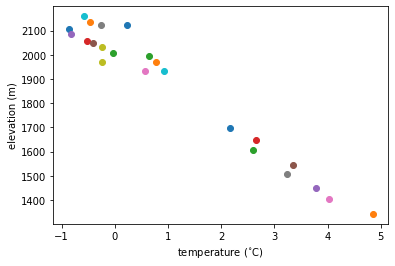

In [ ]:
fig = plt.figure()
for jj, col in enumerate(list(dfm_mean_c8.index)):
    plt.plot(dfm_mean_c8[col], site_elevs[col], 'o', label=site_elevs[col])
plt.xlabel(r'temperature ($^{\circ}$C)')
plt.ylabel('elevation (m)')
plt.show()

In [ ]:
import numpy as np
NUM_SUNSTORM_SENSORS = 8

num_sensors = int(NUM_CLEAVER_SENSORS/2) + NUM_C8_SENSORS + NUM_SUNSTORM_SENSORS

Ts = np.empty(num_sensors)
elvs = np.empty(num_sensors)
heather_Ts = np.empty(int(NUM_CLEAVER_SENSORS/2))
c8_Ts = np.empty(NUM_C8_SENSORS)
sunstorm_Ts = np.empty(NUM_SUNSTORM_SENSORS)
heather_elvs = np.empty(int(NUM_CLEAVER_SENSORS/2))
c8_elvs = np.empty(NUM_C8_SENSORS)
sunstorm_elvs = np.empty(NUM_SUNSTORM_SENSORS)
for jj, col in enumerate(list(dfm_mean_c8.index)[:int(NUM_CLEAVER_SENSORS/2)]):
    heather_Ts[jj] = dfm_mean_c8[col]
    heather_elvs[jj] = site_elevs[col]
for jj, col in enumerate(list(dfm_mean_c8.index)[int(NUM_CLEAVER_SENSORS/2):int(NUM_CLEAVER_SENSORS/2)+NUM_C8_SENSORS]):
    c8_Ts[jj] = dfm_mean_c8[col]
    c8_elvs[jj] = site_elevs[col]
for jj, col in enumerate(list(dfm_mean_c8.index)[int(NUM_CLEAVER_SENSORS/2)+NUM_C8_SENSORS:num_sensors]):
    sunstorm_Ts[jj] = dfm_mean_c8[col]
    sunstorm_elvs[jj] = site_elevs[col]
for jj, col in enumerate(list(dfm_mean_c8.index)):
    Ts[jj] = dfm_mean_c8[col]
    elvs[jj] = site_elevs[col]

In [ ]:
from scipy import stats

significance_threshold = 0.05

r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.9814752891039209
P-value = 1.488802297285285e-16
Slope =  -0.006554697398172658
Intercept =  13.324868917546874


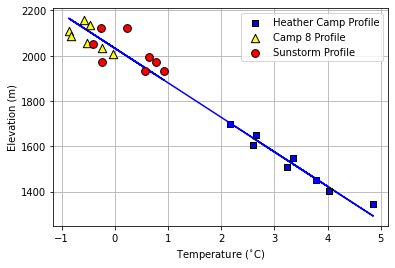

In [ ]:
elvs_predict = (Ts - intercept) / slope

fig = plt.figure()
plt.grid()
plt.plot(Ts, elvs_predict, '-', color='blue')
plt.scatter(heather_Ts, heather_elvs, marker='s', color='blue', edgecolor='black', label='Heather Camp Profile', zorder=4)
plt.scatter(c8_Ts, c8_elvs, marker='^', s=70, color='yellow', edgecolor='black', label='Camp 8 Profile', zorder=4)
plt.scatter(sunstorm_Ts, sunstorm_elvs, marker='o', s=60, color='red', edgecolor='black', label='Sunstorm Profile', zorder=4)
plt.xlabel(r'Temperature ($^{\circ}$C)')
plt.ylabel('Elevation (m)')
plt.legend()
plt.savefig('Figures/Lapse Rate Regression.png', dpi=300, bbox_inches='tight')
plt.show()

# Look at just C8 data

In [ ]:
dfm_clip_c8 = dfm[(dfm['time'] >= datetime(2022, 7, 21, 18, 0, 0)) & 
                  (dfm['time'] <= datetime(2022, 7, 23, 8, 0, 0))]
dfm_clip_c8.head(3)

NameError: ignored

In [ ]:
# Remove irrelevant rows from dataframe
dfm_clip_c8 = dfm_clip_c8[['F_c8', 'P_c8', 'L_c8', 'T_c8', 'N_c8', 'I_c8', 'Q_c8']]
dfm_clip_c8.head(10)

NameError: ignored

In [ ]:
dfm_mean_c8 = dfm_clip_c8.mean(numeric_only=True)
dfm_mean_c8

In [ ]:
import numpy as np

num_sensors = NUM_C8_SENSORS

Ts = np.empty(num_sensors)
elvs = np.empty(num_sensors)
for jj, col in enumerate(list(dfm_mean_c8.index)):
    Ts[jj] = dfm_mean_c8[col]
    elvs[jj] = site_elevs[col]

In [ ]:
from scipy import stats

significance_threshold = 0.05

r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

In [ ]:
elvs_predict = (Ts - intercept) / slope

fig = plt.figure()
plt.plot(Ts, elvs, 'o')
plt.plot(Ts, elvs_predict, '-')
plt.xlabel(r'temperature ($^{\circ}$C)')
plt.ylabel('elevation (m)')
plt.show()

In [ ]:
# TODO: plot hourly temperatures at C8; try fit without outlier (top two) points at C8

In [ ]:
import numpy as np

num_sensors = int(NUM_CLEAVER_SENSORS/2) + NUM_C8_SENSORS

Ts = np.empty(num_sensors)
elvs = np.empty(num_sensors)
for jj, col in enumerate(list(dfm_mean_c8.index)):
    Ts[jj] = dfm_mean_c8[col]
    elvs[jj] = site_elevs[col]

In [ ]:
from scipy import stats

significance_threshold = 0.05

r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.9936510629228879
P-value = 1.0099420792770088e-13
Slope =  -0.006837064758812846
Intercept =  13.753219989877724


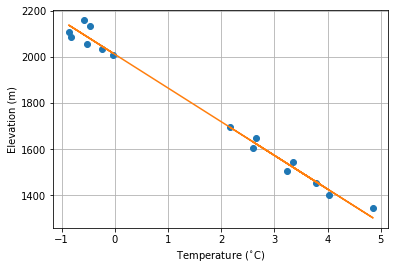

In [ ]:
elvs_predict = (Ts - intercept) / slope

fig = plt.figure()
plt.plot(Ts, elvs, 'o')
plt.plot(Ts, elvs_predict, '-')
plt.xlabel(r'Temperature ($^{\circ}$C)')
plt.ylabel('Elevation (m)')
plt.grid()
# plt.savefig('/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/overall_transect.png', dpi=300, bbox_inches='tight')
plt.show()

# Example plot of lapse rates in arctic vs tropics

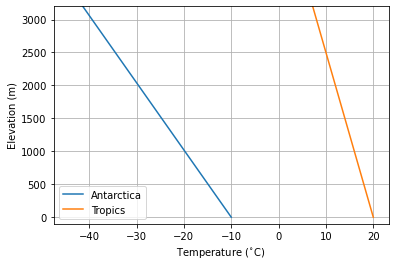

In [ ]:
elevations = np.arange(0, 3500)
antarctica_Ts = -10 - elevations*0.0098
tropics_Ts = 20 - elevations*0.004

plt.plot(antarctica_Ts, elevations, label='Antarctica')
plt.plot(tropics_Ts, elevations, label='Tropics')
plt.ylim(-100, 3200)
plt.xlabel(r'Temperature ($^{\circ}$C)')
plt.ylabel('Elevation (m)')
plt.legend()
plt.grid()
plt.savefig('/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/example_lapse.png', dpi=300, bbox_inches='tight')
plt.show()

# DEM (A big mess)

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/My Drive"

Mounted at /content/drive
 Benoit_Cover_Letter.docx		     JIF_DEM_1000m.tif
 Benoit_CoverLetter.gdoc		     JIF_DEM.tif
 Benoit_Resume.gdoc			    'JIRP Gear notes.gdoc'
 Benoit_Resume.pdf			    'NASA Develop Supplements.gdoc'
'Copy of Benoit_Cover_Letter.docx'	     NewEEImage
'Copy of Copy of Benoit_Cover_Letter.docx'   Research_Colab_Notebooks
 EEPS1960D_MachineLearning		     SciViz
 EE_Trends				     SeaIceVisual.ipynb
'Everything!'				     SURF_UG
 geekfile.txt				     Volcanology
'Google Buzz'				    'Waterspout Research'
'JIF DEM'				     WindPLevel0_3000ft_1DegRes


In [ ]:
!pip install rasterio

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 19.3 MB 385 kB/s 


In [ ]:
import glob
import xarray as xr
geotiff_path = "/content/drive/MyDrive/JIF_DEM_1000m.tif"


# Open into an xarray.DataArray
geotiff_da = xr.open_rasterio(geotiff_path)

# Covert our xarray.DataArray into a xarray.Dataset
geotiff_ds = geotiff_da.to_dataset('band')

# Rename the variable to a more useful name
geotiff_ds = geotiff_ds.rename({1: 'red'})

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DeprecationWarning: open_rasterio is Deprecated in favor of rioxarray. For information about transitioning, see: https://corteva.github.io/rioxarray/stable/getting_started/getting_started.html
  import sys


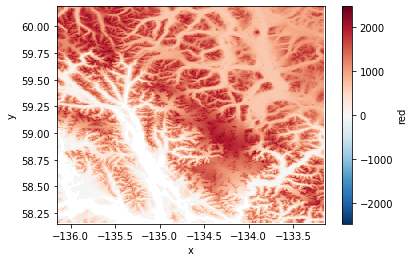

In [ ]:
geotiff_ds.red.plot()


In [ ]:
import numpy as np

DEM = np.squeeze(np.array(geotiff_ds.as_numpy().to_array()))
np.shape(DEM)

(227, 335)

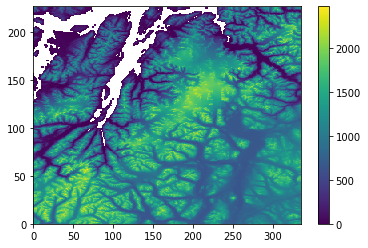

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.pcolor(DEM)
plt.colorbar()
plt.show()

128676

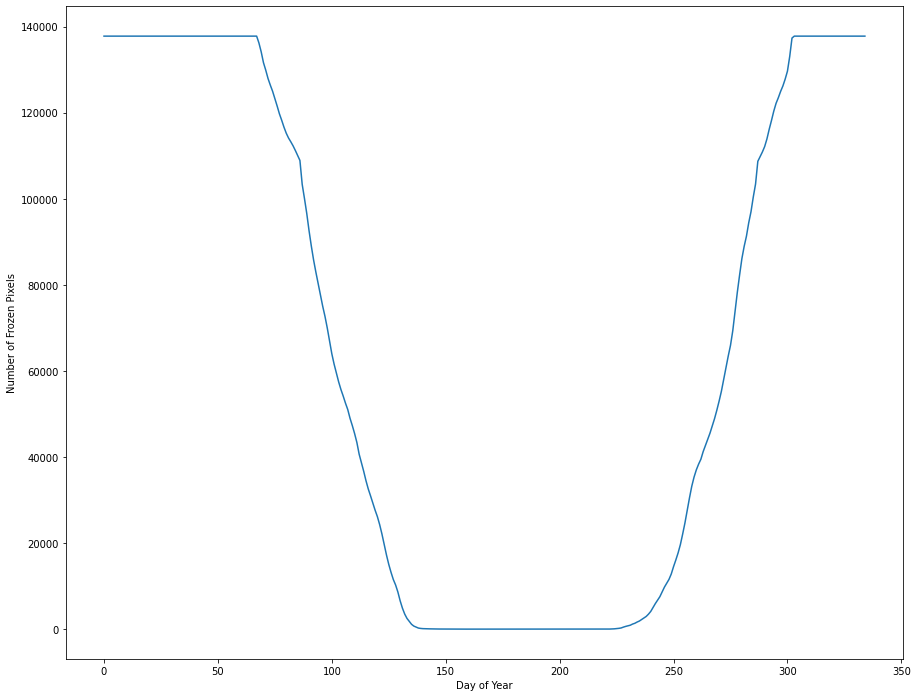

In [ ]:
Isotherm = np.array([-567.5930627486924,
                      -518.7854917747492,
                      -444.1954876518363,
                      -419.38539081751185,
                      -405.02077612301883,
                      -365.74692786581846,
                      -334.9071458182032,
                      -295.5986846266286,
                      -284.8043963848765,
                      -287.0549231180029,
                      -297.5026208656147,
                      -275.9387126468893,
                      -275.92078902079885,
                      -301.46040125174295,
                      -310.83158647786536,
                      -316.82261021301264,
                      -318.4744420004603,
                      -355.98589239720144,
                      -365.8582543191746,
                      -363.02520683626847,
                      -363.987659187214,
                      -369.35717387908454,
                      -370.19280743805786,
                      -359.6765128067793,
                      -355.5638621409134,
                      -344.61688715280064,
                      -335.70777236934686,
                      -309.99839852974725,
                      -278.61838273293745,
                      -249.601967178646,
                      -224.2321719897769,
                      -229.67283465920406,
                      -261.1683373705895,
                      -290.7400411092574,
                      -324.6059185075422,
                      -357.50928082958075,
                      -364.50335400955726,
                      -378.4674732808881,
                      -381.3905391810724,
                      -361.52670895879817,
                      -341.3893268640418,
                      -332.5388962326914,
                      -327.4173213376713,
                      -306.0621445887447,
                      -303.22894458542413,
                      -307.4809186682501,
                      -317.0028063673463,
                      -326.23370171142403,
                      -321.2006529080861,
                      -323.5772479677229,
                      -332.676328252383,
                      -325.8627257607683,
                      -308.27338837436764,
                      -291.19469818344993,
                      -264.8411114736516,
                      -234.68041320855335,
                      -205.9089631944797,
                      -196.57189363125877,
                      -180.35834698267223,
                      -163.15844238952104,
                      -155.7500671873997,
                      -148.21627996419895,
                      -137.8430925096682,
                      -122.6836390459888,
                      -95.06051691412624,
                      -69.53443745069188,
                      -45.58064444743601,
                      -13.383148416108419,
                      10.895334318295616,
                      26.132930888990693,
                      51.38417718358981,
                      76.49631223101943,
                      116.30144037413152,
                      154.29091872400468,
                      192.6156677856878,
                      239.69651287114192,
                      286.96194564515145,
                      342.9444518941297,
                      385.3925604515148,
                      429.1360997735688,
                      467.6752389630601,
                      497.7413533989203,
                      522.681954527186,
                      547.4200252701897,
                      575.6240728355583,
                      605.611759929288,
                      635.9230355791767,
                      671.0146675748715,
                      704.4007325898484,
                      733.5285640614266,
                      772.1378300091177,
                      810.1516181401145,
                      847.9514158258339,
                      877.5968451542168,
                      906.1983468693769,
                      932.7295318720857,
                      956.2415771343753,
                      979.3632852582449,
                      1007.1698228262209,
                      1037.3225743048247,
                      1068.4771318714138,
                      1093.174318660834,
                      1115.3768706976225,
                      1137.063085828271,
                      1156.3514134053405,
                      1172.8976444786044,
                      1191.1902941758801,
                      1207.6746014026785,
                      1230.6819168344916,
                      1249.1960361000527,
                      1270.495950427374,
                      1294.0092595794551,
                      1324.145615453035,
                      1348.1441001338826,
                      1370.2911631309546,
                      1396.2318056910576,
                      1420.7593019710891,
                      1440.542768491439,
                      1461.9313656023037,
                      1483.2405420296584,
                      1501.4088632826101,
                      1526.2128341875202,
                      1556.3546271105413,
                      1590.5985306824764,
                      1624.7227522808578,
                      1659.1695559743619,
                      1690.5259099421148,
                      1720.3139934171663,
                      1745.7695101316185,
                      1779.3289741589354,
                      1823.102523187837,
                      1866.3997638344633,
                      1909.5787361769178,
                      1949.7700719614122,
                      1984.1799775803577,
                      2027.1625647663518,
                      2065.309735538308,
                      2105.6743686435907,
                      2141.612021828375,
                      2173.6887542947866,
                      2198.5358860593665,
                      2217.349937036983,
                      2225.8819594557194,
                      2233.9539071647564,
                      2245.947688855757,
                      2255.130264805051,
                      2264.404433234601,
                      2271.627471860906,
                      2279.4798767639504,
                      2286.5185811997794,
                      2299.4237486514016,
                      2316.6745562270085,
                      2337.356669921352,
                      2348.91568870335,
                      2359.663687986032,
                      2366.9173207121567,
                      2373.964311758808,
                      2385.30449735513,
                      2400.5859078949143,
                      2407.1807633645776,
                      2397.7933748231476,
                      2397.6657868783045,
                      2394.489309387019,
                      2398.8007037521247,
                      2411.8805499016958,
                      2415.715877008561,
                      2428.895515069194,
                      2434.9067923681882,
                      2445.5759917766222,
                      2467.454950752735,
                      2496.532829975045,
                      2520.896069874334,
                      2536.617230776627,
                      2552.172051062058,
                      2561.7333464389453,
                      2570.9028586840373,
                      2575.4507886769907,
                      2588.1808236780644,
                      2612.2597893372313,
                      2637.3227248271464,
                      2659.5117676992486,
                      2689.7214537435084,
                      2706.2969975606215,
                      2721.644218607799,
                      2738.3579166939094,
                      2757.751882534874,
                      2773.922796946585,
                      2790.3403012031144,
                      2801.796445086414,
                      2806.76771281455,
                      2807.1544292794147,
                      2797.576309948082,
                      2803.418334098831,
                      2810.7513334457976,
                      2821.1425398452234,
                      2829.8871109570136,
                      2832.656117608602,
                      2841.3551559754696,
                      2847.010524569064,
                      2839.2480511874132,
                      2811.378970127646,
                      2785.0051277685766,
                      2773.1246132728293,
                      2753.1016557041316,
                      2729.9384949743608,
                      2707.9138180410664,
                      2690.130224740678,
                      2671.5092699781258,
                      2645.0484754115055,
                      2617.7706707021002,
                      2593.2413067367825,
                      2559.208048647717,
                      2533.254644348153,
                      2508.6864085694415,
                      2485.047521508393,
                      2463.3460193339033,
                      2434.929123135801,
                      2405.6635991241296,
                      2377.269467036039,
                      2355.0100994423506,
                      2334.1759371426124,
                      2315.6090574729246,
                      2286.1879302575876,
                      2254.3073823423433,
                      2224.8067958915317,
                      2197.0397446492857,
                      2166.5403261666734,
                      2136.1154920041768,
                      2105.82552001394,
                      2076.41850313129,
                      2059.03668342676,
                      2044.73212489676,
                      2024.4669469445837,
                      2010.9168819607341,
                      1992.5749074496825,
                      1977.287949249439,
                      1961.286434023926,
                      1946.3630676146308,
                      1930.7221780036105,
                      1910.5109067435524,
                      1888.0915794909758,
                      1861.6192492128644,
                      1838.7295032427387,
                      1819.147230255057,
                      1801.3381741166731,
                      1778.7643558090936,
                      1756.7387280253784,
                      1737.3494893432578,
                      1719.6356563951576,
                      1696.2725414254628,
                      1667.978135422687,
                      1641.7243752247339,
                      1617.4604014075219,
                      1590.495120269775,
                      1556.6931788411268,
                      1520.9952347653934,
                      1484.3491421760625,
                      1446.6464205211053,
                      1412.3050876283912,
                      1385.9953258080434,
                      1366.4923977813953,
                      1351.3674912127472,
                      1337.6980128168932,
                      1317.5599210093237,
                      1301.9845986621065,
                      1285.718829144736,
                      1269.3587215610405,
                      1250.1359198631962,
                      1231.4872382704598,
                      1209.3928185552902,
                      1185.5753327771401,
                      1161.2715342660092,
                      1131.4063830910075,
                      1103.0156385949108,
                      1074.3975147926108,
                      1048.067368229955,
                      1013.340230432099,
                      968.3445941915514,
                      925.4180715634691,
                      884.298897877301,
                      844.646024407789,
                      811.1471585564999,
                      784.9150589394069,
                      754.7368709776008,
                      730.1738918862849,
                      701.1638170148566,
                      670.0912621869645,
                      641.8847094045123,
                      613.7633958104097,
                      584.4540790117618,
                      551.9653530730943,
                      503.9406881185305,
                      442.53624993118217,
                      386.49387159053026,
                      321.9088208800394,
                      269.65915375620136,
                      233.87525631228308,
                      193.95173021860788,
                      160.08989437431717,
                      119.76109015156753,
                      81.46403270569795,
                      36.07403478031986,
                      1.517342320077554,
                      -24.42435432967275,
                      -64.83465442034097,
                      -112.9162823607109,
                      -163.11915115004277,
                      -203.13397641957957,
                      -242.86647936331576,
                      -269.96710199011767,
                      -308.6136069069485,
                      -317.16758280844795,
                      -329.9639740136904,
                      -339.7030395075044,
                      -369.69643024887506,
                      -370.9887002579503,
                      -373.93235728950225,
                      -383.1106427555343,
                      -394.47960147986885,
                      -418.15565118741847,
                      -429.35080680312024,
                      -455.8070355841014,
                      -456.90375872237166,
                      -451.11805525435926,
                      -452.07997152866915,
                      -470.5590183640531,
                      -484.2972890261901,
                      -462.5844365019242,
                      -463.31343375118087,
                      -440.29887515400463,
                      -432.0793122779787,
                      -422.8494397192754,
                      -421.87066305101223,
                      -422.6670130545535,
                      -423.1001976812673])

Area = np.zeros([len(Isotherm),1]) * np.nan
for i in range(len(Isotherm)):
  Area[i] = np.size(np.where(DEM>Isotherm[i]))

plt.figure(figsize=(15,12))
plt.plot(Area)
plt.ylabel("Number of Frozen Pixels")
plt.xlabel("Day of Year")
plt.show()

In [ ]:
np.where(DEM>100)

(array([  0,   0,   0, ..., 225, 225, 225]),
 array([  0,   1,   2, ..., 331, 332, 333]))